In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from function.library import *

from sklearn.linear_model import LogisticRegression


In [2]:
X_train = pd.read_csv('../data/X_train.csv')   
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

In [3]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nTraining Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest Distribution:")
print(pd.Series(y_test).value_counts())

Train Shape: (759384, 23)
Test Shape: (118799, 23)

Training Distribution:
1.0    379692
0.0    379692
Name: count, dtype: int64

Test Distribution:
1.0    94802
0.0    23997
Name: count, dtype: int64


In [4]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=100000,
    stratify=y_train,
    random_state=42
)

print("Tuning Shape:", X_tune.shape)
print(pd.Series(y_tune).value_counts())

Tuning Shape: (100000, 23)
1.0    50000
0.0    50000
Name: count, dtype: int64


In [5]:
lr_baseline = LogisticRegression(
    random_state=42,
    max_iter=1000
)

start_time = time.time()

lr_baseline.fit(X_train, y_train)

baseline_train_time = time.time() - start_time

print("Baseline LR trained successfully.")
print("Training Time:", round(baseline_train_time, 2), "seconds")

Baseline LR trained successfully.
Training Time: 2.66 seconds


In [6]:
y_pred_base = lr_baseline.predict(X_test)
y_prob_base = lr_baseline.predict_proba(X_test)[:, 1]

In [7]:
baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
    "ROC-AUC": roc_auc_score(y_test, y_prob_base),
    "Log Loss": log_loss(y_test, y_prob_base),
    "Brier Score": brier_score_loss(y_test, y_prob_base),
    "Training Time": baseline_train_time
}

baseline_df = pd.DataFrame(
    baseline_results.items(),
    columns=["Metric", "Baseline LR"]
)

baseline_df

,Metric,Baseline LR
0,Accuracy,0.863290
1,Precision,0.935980
2,Recall,0.889528
3,F1 Score,0.912163
4,ROC-AUC,0.908983
5,Log Loss,0.344554
6,Brier Score,0.104495
7,Training Time,2.661663


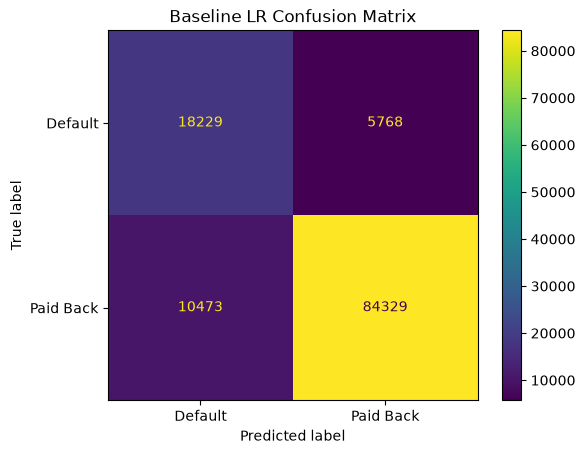

In [8]:
cm = confusion_matrix(y_test, y_pred_base)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Default", "Paid Back"]
)

disp.plot(values_format='d')

plt.title("Baseline LR Confusion Matrix")
plt.show()

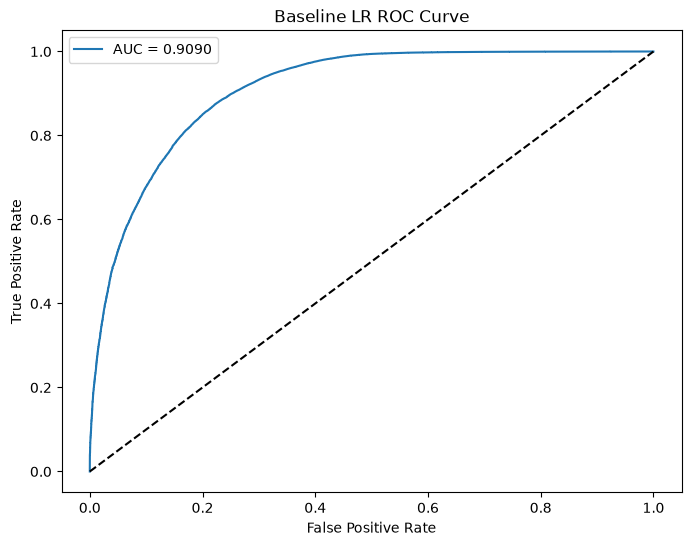

In [9]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_base
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_prob_base):.4f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline LR ROC Curve")
plt.legend()

plt.show()

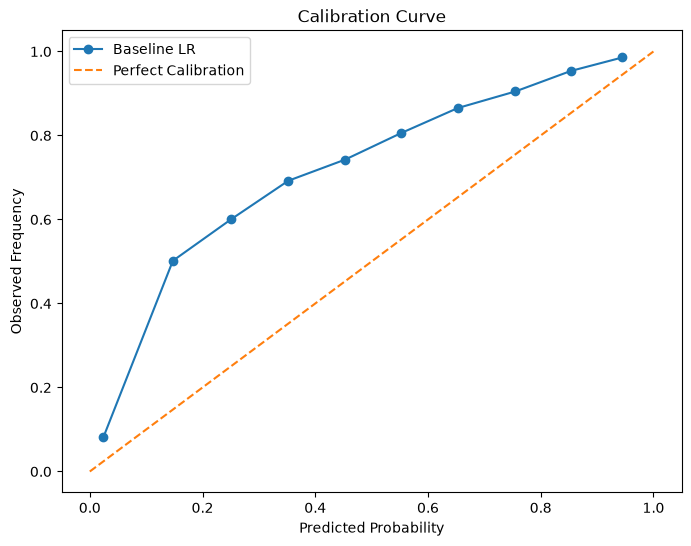

In [10]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_base,
    n_bins=10
)

plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Baseline LR'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()

plt.show()

In [11]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

level1_param_grid = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.005, 0.01, 0.05, 0.1, 0.15, 0.2]
    },
    {
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
        'penalty': ['l2'],
        'C': [0.005, 0.01, 0.05, 0.1, 0.15, 0.2]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1'],
        'C': [0.005, 0.01, 0.05, 0.1, 0.15, 0.2]
    },
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': [0.005, 0.01, 0.05, 0.1, 0.15, 0.2],
        'l1_ratio': [0.2, 0.5, 0.8]
    }
]

In [12]:
# GridSearchCV

level1_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    param_grid=level1_param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

start_time = time.time()

level1_grid.fit(X_tune, y_tune)

tuning_time = time.time() - start_time

print("Best Parameters:")
print(level1_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(level1_grid.best_score_)

print("\nTuning Time:", round(tuning_time, 2), "seconds")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters:
{'C': 0.2, 'penalty': 'l1', 'solver': 'liblinear'}

Best CV ROC-AUC:
0.918350646

Tuning Time: 121.54 seconds


In [13]:
level2_param_grid = {
    "solver": ["liblinear"],
    "penalty": ["l1"],
    "C": [0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
}


In [14]:
level2_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    param_grid=level2_param_grid,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1,
    verbose=2
)

level2_grid.fit(X_tune, y_tune)

print("Best Parameters:")
print(level2_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(level2_grid.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters:
{'C': 0.2, 'penalty': 'l1', 'solver': 'liblinear'}

Best CV ROC-AUC:
0.918350646


In [ ]:

best_index = level2_grid.best_index_

lr_fold_auc = np.array([
    level2_grid.cv_results_[
        f"split{i}_test_score"
    ][best_index]
    for i in range(5)
])

print("LR Fold-Level ROC-AUC:")
for i, score in enumerate(lr_fold_auc, start=1):
    print(f"Fold {i}: {score:.6f}")

print(
    "\nMean ROC-AUC:",
    f"{lr_fold_auc.mean():.6f}"
)

LR Fold-Level ROC-AUC:
Fold 1: 0.916431
Fold 2: 0.919765
Fold 3: 0.918104
Fold 4: 0.919031
Fold 5: 0.918422

Mean ROC-AUC: 0.918351


In [16]:
#final model training with best parameters
best_params = level2_grid.best_params_

final_lr = LogisticRegression(
    **best_params,
    max_iter=3000,
    random_state=42
)

start_time = time.time()

final_lr.fit(X_train, y_train)

final_train_time = time.time() - start_time

print("Final tuned LR trained successfully.")
print("Final Training Time:", round(final_train_time, 2), "seconds")

Final tuned LR trained successfully.
Final Training Time: 34.03 seconds


In [17]:
y_pred_tuned = final_lr.predict(X_test)
y_prob_tuned = final_lr.predict_proba(X_test)[:, 1]

tuned_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1 Score": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned),
    "Log Loss": log_loss(y_test, y_prob_tuned),
    "Brier Score": brier_score_loss(y_test, y_prob_tuned),
    "Training Time": final_train_time
}

tuned_df = pd.DataFrame(
    tuned_results.items(),
    columns=["Metric", "Tuned LR"]
)

tuned_df

,Metric,Tuned LR
0,Accuracy,0.863324
1,Precision,0.936060
2,Recall,0.889485
3,F1 Score,0.912179
4,ROC-AUC,0.908984
5,Log Loss,0.344576
6,Brier Score,0.104507
7,Training Time,34.034244


In [18]:
comparison_df = pd.DataFrame({
    "Metric": baseline_results.keys(),
    "Baseline LR": baseline_results.values(),
    "Tuned LR": tuned_results.values()
})

comparison_df

,Metric,Baseline LR,Tuned LR
0,Accuracy,0.863290,0.863324
1,Precision,0.935980,0.936060
2,Recall,0.889528,0.889485
3,F1 Score,0.912163,0.912179
4,ROC-AUC,0.908983,0.908984
5,Log Loss,0.344554,0.344576
6,Brier Score,0.104495,0.104507
7,Training Time,2.661663,34.034244


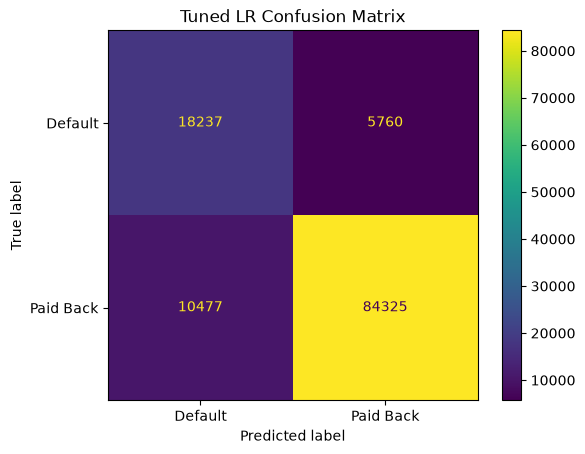

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred_tuned
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Default", "Paid Back"]
)

disp.plot(values_format='d')

plt.title("Tuned LR Confusion Matrix")
plt.show()

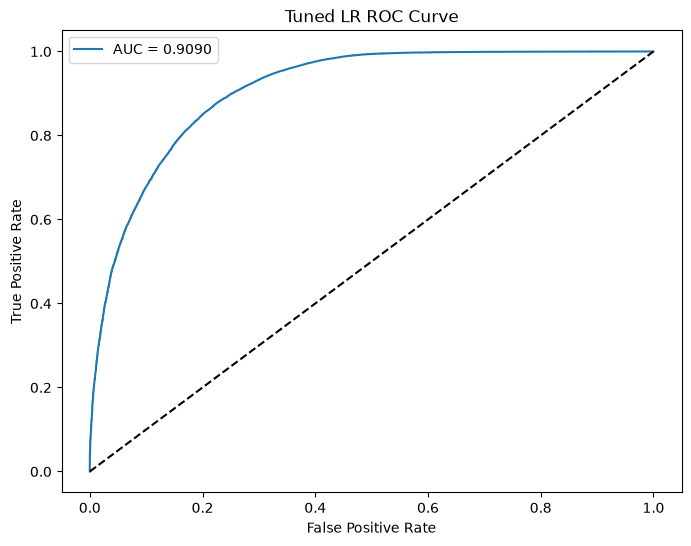

In [20]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_tuned
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_prob_tuned):.4f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned LR ROC Curve")
plt.legend()

plt.show()

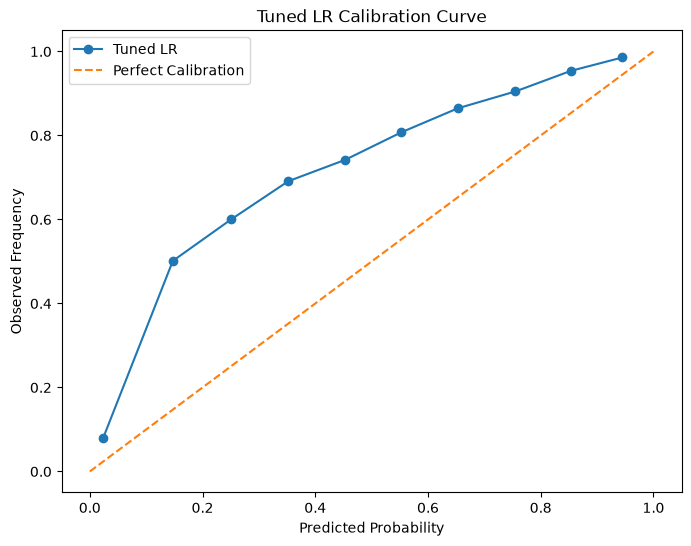

In [21]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_tuned,
    n_bins=10
)

plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Tuned LR'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Tuned LR Calibration Curve")
plt.legend()

plt.show()

In [22]:
lr_best_parameters = pd.DataFrame({
    "Search Level": ["Level 1", "Level 2"],
    "Best C": [
        level1_grid.best_params_["C"],
        level2_grid.best_params_["C"]
    ],
    "Best Penalty": [
        level1_grid.best_params_["penalty"],
        level2_grid.best_params_["penalty"]
    ],
    "Best Solver": [
        level1_grid.best_params_["solver"],
        level2_grid.best_params_["solver"]
    ],
    "Best Mean ROC-AUC": [
        level1_grid.best_score_,
        level2_grid.best_score_
    ]
})

lr_best_parameters.to_csv(
    "../results/lr_best_parameters.csv",
    index=False
)

print("Best parameters saved successfully.")

Best parameters saved successfully.


In [23]:
joblib.dump(
    final_lr,
    '../models/lr_model.pkl'
)

print("Model saved successfully.")

Model saved successfully.


In [24]:
comparison_df.to_csv(
    '../results/lr_comparison_metrics.csv',
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.


In [25]:
joblib.dump(X_train.columns.tolist(), "../models/model_columns.pkl")

['../models/model_columns.pkl']